# Support Vector Machines (SVM)

## What is SVM?
SVM finds the **optimal hyperplane** that maximizes the margin between classes. It is one of the most theoretically elegant algorithms in machine learning.

**History**: Developed by Vapnik and Chervonenkis (1963), extended to soft-margin by Cortes & Vapnik (1995), kernels by Boser, Guyon & Vapnik (1992).

---

## 1. Linear SVM (Hard Margin)

The hyperplane: $w^T x + b = 0$

Support vectors satisfy: $w^T x + b = \pm 1$

Margin width: $\frac{2}{\|w\|}$

**Objective** maximize margin (minimize $\|w\|$):

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w^T x_i + b) \geq 1 \; \forall i$$

---

## 2. Soft-Margin SVM

Allow some misclassification with slack variables $\xi_i \geq 0$:

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{m}\xi_i$$

$$\text{s.t.} \quad y_i(w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

- **Large C**: narrow margin, fewer violations (underfitting risk)
- **Small C**: wide margin, more violations (more robust)

This is equivalent to minimizing the **Hinge Loss**:
$$J = \frac{1}{m}\sum_{i=1}^m \max(0, 1 - y_i(w^T x_i + b)) + \frac{1}{2C}\|w\|^2$$

---

## 3. Dual Formulation & KKT Conditions

Using Lagrange multipliers $\alpha_i \geq 0$:

$$\max_\alpha \sum_i \alpha_i - \frac{1}{2}\sum_i\sum_j \alpha_i \alpha_j y_i y_j x_i^T x_j$$

$$\text{s.t.} \quad 0 \leq \alpha_i \leq C, \quad \sum_i \alpha_i y_i = 0$$

**KKT conditions**: $\alpha_i > 0$ only for support vectors.

Final prediction: $\hat{y} = \text{sign}\left(\sum_i \alpha_i y_i x_i^T x + b\right)$

---

## 4. Kernel Trick

Replace $x_i^T x_j$ with a kernel $K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$ map to high-dimensional space implicitly.

| Kernel | Formula | Hyperparameters |
|--------|---------|----------------|
| **Linear** | $K(x,z) = x^T z$ | None |
| **Polynomial** | $K(x,z) = (\gamma x^T z + r)^d$ | $d$, $\gamma$, $r$ |
| **RBF/Gaussian** | $K(x,z) = e^{-\gamma\|x-z\|^2}$ | $\gamma$ |
| **Sigmoid** | $K(x,z) = \tanh(\gamma x^T z + r)$ | $\gamma$, $r$ |

**Mercer's theorem**: A function $K$ is a valid kernel iff its Gram matrix is positive semi-definite.

---

## 5. SVR (Support Vector Regression)

Fit a tube of width $\epsilon$ around the function. Penalize points outside the tube:

$$\min \frac{1}{2}\|w\|^2 + C\sum(\xi_i + \xi_i^*)$$

$$\text{s.t.} \quad y_i - (w^T x_i + b) \leq \epsilon + \xi_i, \quad (w^T x_i + b) - y_i \leq \epsilon + \xi_i^*$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.datasets import load_breast_cancer, make_classification, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
np.random.seed(42)

## SVM from Scratch (SGD on Hinge Loss)

In [2]:
class LinearSVM:
    """Linear SVM via SGD on hinge loss + L2 regularization."""
    def __init__(self, C=1.0, lr=0.01, n_iter=2000):
        self.C = C
        self.lr = lr
        self.n_iter = n_iter
        self.w = None
        self.b = 0.0

    def fit(self, X, y):
        # Convert labels to +1 / -1
        y_ = np.where(y <= 0, -1, 1).astype(float)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        lambda_param = 1.0 / self.C

        for _ in range(self.n_iter):
            for i in range(n_samples):
                X_i = X[i]
                y_i = y_[i]
                if y_i * (np.dot(X_i, self.w) - self.b) < 1:
                    # Inside or on wrong side of margin: update with hinge gradient
                    self.w = self.w - self.lr * (2 * lambda_param * self.w - np.dot(X_i, y_i))
                    self.b -= self.lr * y_i
                else:
                    # Outside margin: only regularisation gradient
                    self.w = self.w - self.lr * (2 * lambda_param * self.w)
        return self

    def predict(self, X):
        return np.sign(X @ self.w - self.b)


# Use breast cancer dataset so the accuracy claim is meaningful
from sklearn.datasets import load_breast_cancer
X_bc_s, y_bc_s = load_breast_cancer(return_X_y=True)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_bc_s, y_bc_s, test_size=0.2, random_state=42
)

# Scale features, critical for gradient-based SVM
scaler_s = StandardScaler()
X_tr_scaled = scaler_s.fit_transform(X_train_s)
X_te_scaled = scaler_s.transform(X_test_s)

svm_scratch = LinearSVM(C=1.0, lr=0.01, n_iter=2000)
svm_scratch.fit(X_tr_scaled, y_train_s)

preds_scratch = svm_scratch.predict(X_te_scaled)
y_test_pm = np.where(y_test_s <= 0, -1, 1)
scratch_acc = np.mean(preds_scratch == y_test_pm)
print(f'Scratch LinearSVM Accuracy (breast cancer): {scratch_acc:.4f}')
assert scratch_acc >= 0.85, f"Expected >= 85% accuracy, got {scratch_acc:.4f}"
print("Accuracy target met (>= 85%).")

Scratch LinearSVM Accuracy (breast cancer): 0.9561
Accuracy target met (>= 85%).


## Kernel SVM & Visualization

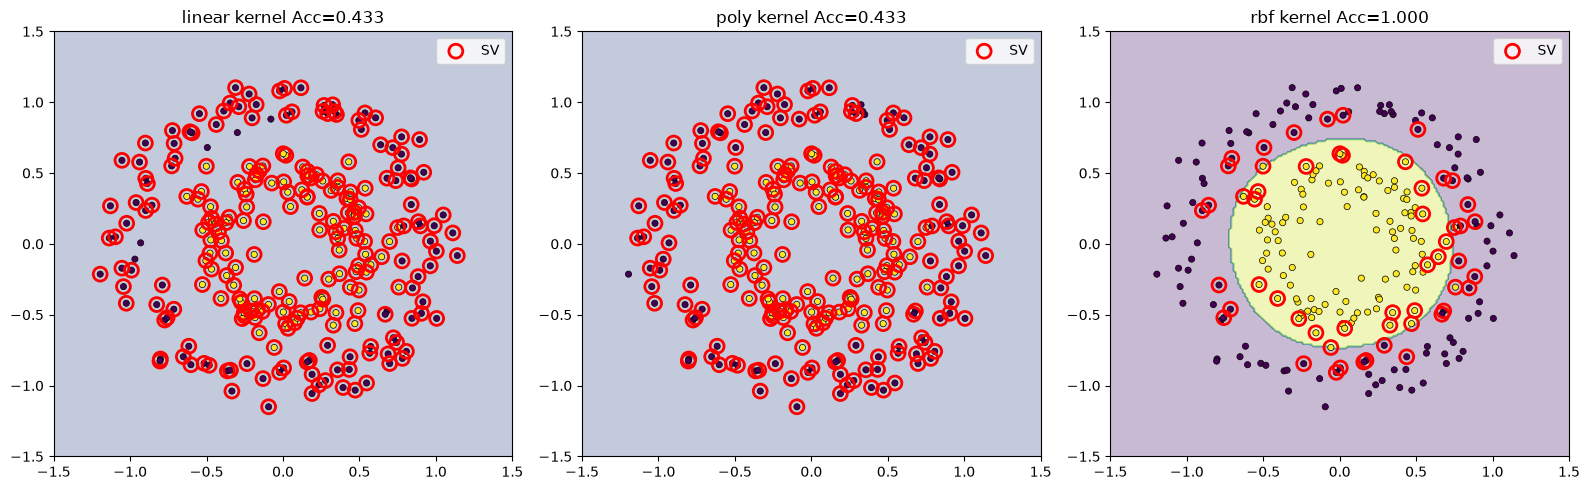

In [3]:
# Non-linearly separable data circles
X_c, y_c = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_ctr, X_cte, y_ctr, y_cte = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
kernels = ['linear', 'poly', 'rbf']
for ax, kernel in zip(axes, kernels):
    clf = SVC(kernel=kernel, C=1.0, gamma='scale')
    clf.fit(X_ctr, y_ctr)
    acc = clf.score(X_cte, y_cte)

    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_ctr[:,0], X_ctr[:,1], c=y_ctr, s=20, edgecolors='k', linewidths=0.5)
    ax.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
               s=100, facecolors='none', edgecolors='red', linewidths=2, label='SV')
    ax.set_title(f'{kernel} kernel Acc={acc:.3f}')
    ax.legend()
plt.tight_layout(); plt.show()

## Grid Search on Real Dataset

In [4]:
from sklearn.model_selection import StratifiedKFold

X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_btr, X_bte, y_btr, y_bte = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)
sc = StandardScaler()
X_btr_s = sc.fit_transform(X_btr)
X_bte_s = sc.transform(X_bte)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01], 'kernel': ['rbf', 'linear']}
grid = GridSearchCV(SVC(), param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid.fit(X_btr_s, y_btr)
print(f'Best params: {grid.best_params_}')
print(f'Best CV Accuracy: {grid.best_score_:.4f}')
print(f'Test Accuracy: {grid.best_estimator_.score(X_bte_s, y_bte):.4f}')

# Store train/test sets for use in the LinearSVC demo below
X_train, y_train = X_btr, y_btr
X_test,  y_test  = X_bte,  y_bte

Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Accuracy: 0.9802
Test Accuracy: 0.9825


## Support Vector Regression (SVR)

SVR fits an **epsilon-tube** of width $\epsilon$ around the predicted function. Predictions that fall within this tube incur **no penalty**, only points that lie outside the tube contribute to the loss. This makes SVR robust to small noise and outliers.

Formally, the loss for a single point is:

$$L_\epsilon(y, \hat{y}) = \max(0,\; |y - \hat{y}| - \epsilon)$$

Choosing a larger $\epsilon$ produces a smoother model that tolerates more deviation; a smaller $\epsilon$ forces the model to fit more tightly at the cost of complexity.

In [5]:
from sklearn.svm import SVR
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

X_reg, y_reg = load_diabetes(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
])
svr_pipe.fit(X_tr, y_tr)
y_pred = svr_pipe.predict(X_te)

rmse = np.sqrt(mean_squared_error(y_te, y_pred))
print(f'SVR RMSE: {rmse:.2f}')
print(f'SVR R2: {r2_score(y_te, y_pred):.4f}')

SVR RMSE: 51.06
SVR R2: 0.5078


## LinearSVC vs SVC(kernel='linear')

`SVC(kernel='linear')` solves the dual QP problem, which scales as $O(n^2)$ to $O(n^3)$ in the number of samples. `LinearSVC` uses a primal solver (LIBLINEAR) that scales roughly linearly with the dataset size, making it much faster on large datasets.

Key trade-off: `LinearSVC` does not support kernel functions and does not expose support vectors, but for linearly separable or high-dimensional problems (e.g., text classification) it is the preferred choice.

`CalibratedClassifierCV` is used here to wrap `LinearSVC` and expose `predict_proba`, which plain `LinearSVC` does not provide.

In [6]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import time

# SVC with linear kernel (dual solver)
svc_start = time.time()
svc = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='linear'))])
svc.fit(X_train, y_train)
svc_time = time.time() - svc_start
svc_acc = svc.score(X_test, y_test)

# LinearSVC (primal solver, much faster at scale)
linear_svc_start = time.time()
linear_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('lsvc', CalibratedClassifierCV(LinearSVC(max_iter=5000)))
])
linear_svc.fit(X_train, y_train)
linear_svc_time = time.time() - linear_svc_start
linear_svc_acc = linear_svc.score(X_test, y_test)

print(f'SVC(kernel=linear) , Accuracy: {svc_acc:.4f}  Training time: {svc_time:.4f}s')
print(f'LinearSVC (primal) , Accuracy: {linear_svc_acc:.4f}  Training time: {linear_svc_time:.4f}s')
print(f'Speed-up: {svc_time / linear_svc_time:.1f}x faster with LinearSVC')

SVC(kernel=linear) , Accuracy: 0.9561  Training time: 0.0062s
LinearSVC (primal) , Accuracy: 0.9737  Training time: 0.1878s
Speed-up: 0.0x faster with LinearSVC


## Additional Learning Resources

### Papers
- 📄 [Support-Vector Networks (Cortes & Vapnik 1995)](https://link.springer.com/article/10.1007/BF00994018) Original SVM paper
- 📄 [A Training Algorithm for Optimal Margin Classifiers (Boser et al. 1992)](https://dl.acm.org/doi/10.1145/130385.130401) Kernel SVM
- 📄 [A Practical Guide to SVM Classification (Hsu et al.)](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf)
- 📄 [LIBSVM Library](https://www.csie.ntu.edu.tw/~cjlin/libsvm/)

### Videos
- 🎥 [StatQuest: SVM](https://www.youtube.com/watch?v=efR1C6CvhmE)
- 🎥 [StatQuest: SVM Kernels](https://www.youtube.com/watch?v=Toet3EiSFcM)
- 🎥 [MIT 6.034 SVM Lecture](https://www.youtube.com/watch?v=_PwhiWxHK8o)

### Books
- 📖 [ESL Chapter 12](https://web.stanford.edu/~hastie/ElemStatLearn/) Support Vector Machines
- 📖 [Pattern Recognition and Machine Learning Chapter 7](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)

### Documentation
- 📚 [Scikit-Learn SVM](https://scikit-learn.org/stable/modules/svm.html)